In [1]:
import json
from pathlib import Path

import ipywidgets as widgets
from IPython.display import SVG, display
import panel as pn
import panel_material_ui as pmui

from logogen import generate_logo_svg, LogoParams, Roundedness

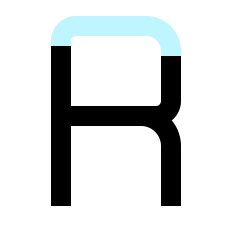

In [2]:
roundedness = Roundedness(
    top_left=15,
    top_right=25,
    mid_right_up=15,
    mid_right_down=30,
)

params = LogoParams(
    width=130,
    height=200,
    line_thickness=20,
    crossbar_pos=0.5,
    roundedness=roundedness,
    cap_color="#bff5ff",
    # base_color="#000000",
)

SVG(
    generate_logo_svg(
        params,
        # allow_invalid=True,
))

# Interactive

In [3]:
# setup objects

params = LogoParams(
    roundedness = Roundedness()
)
svg = pn.pane.SVG(generate_logo_svg(params, allow_invalid=True))

svg

SVG(str, design=<class 'panel_material_ui....)

In [4]:
# colors

pn.extension()


def _on_color(event):
    name = event.obj.name
    val = event.new
    setattr(params, name, val)
    svg.object = generate_logo_svg(params, allow_invalid=True)


cpb = pmui.ColorPicker(name="base_color", value="#000000")
cpb.param.watch(_on_color, "value")
cpc = pmui.ColorPicker(name="cap_color", value="#000000")
cpc.param.watch(_on_color, "value")

Watcher(inst=ColorPicker(design=<class 'panel_material_ui...., label='cap_color', name='cap_color', value='#000000'), cls=<class 'panel_material_ui.widgets.input.ColorPicker'>, fn=<function _on_color at 0x7fc1ae2be980>, mode='args', onlychanged=True, parameter_names=('value',), what='value', queued=False, precedence=0)

In [5]:
# shape

def _on_change(event):
    name = event.obj.name
    val = event.new
    if name.endswith("_rnd"):
        setattr(params.roundedness, name[:-4], val)
    else:
        setattr(params, name, val)
    svg.object = generate_logo_svg(params, allow_invalid=True)


# roundedness
tlr = pn.widgets.IntSlider(value=20, start=0, end=100, name="top_left_rnd")
tlr.param.watch(_on_change, "value")
trr = pn.widgets.IntSlider(value=20, start=0, end=100, name="top_right_rnd")
trr.param.watch(_on_change, "value")
mrur = pn.widgets.IntSlider(value=20, start=0, end=100, name="mid_right_up_rnd")
mrur.param.watch(_on_change, "value")
mrdr = pn.widgets.IntSlider(value=20, start=0, end=100, name="mid_right_down_rnd")
mrdr.param.watch(_on_change, "value")

# shape
width = pn.widgets.IntSlider(value=130, start=50, end=200, name="width")
width.param.watch(_on_change, "value")
height = pn.widgets.IntSlider(value=200, start=100, end=350, name="height")
height.param.watch(_on_change, "value")
xbp = pn.widgets.FloatSlider(value=0.5, start=0.0, end=1.0, step=0.01, name="crossbar_pos")
xbp.param.watch(_on_change, "value")
thickness = pn.widgets.FloatSlider(value=20.0, start=0.0, end=50.0, name="line_thickness")
thickness.param.watch(_on_change, "value")

Watcher(inst=FloatSlider(design=<class 'panel_material_ui...., end=50.0, name='line_thickness', value=20.0), cls=<class 'panel.widgets.slider.FloatSlider'>, fn=<function _on_change at 0x7fc1ae1f8c20>, mode='args', onlychanged=True, parameter_names=('value',), what='value', queued=False, precedence=0)

In [6]:
# save candidates
btn = pn.widgets.Button(name=f"Add Candidate", button_type="primary")

def _write_candidate(_):
    fpath = Path("candidates.json")
    # read existing contents
    if fpath.exists():
        with open(fpath, "r") as f:
            contents = f.read()
            try:
                cands = json.loads(contents)
            except json.JSONDecodeError:
                cands = []
    else:
        cands = []

    # add ours and save
    cur_cand = params.model_dump(mode="json")
    with open(fpath, "w") as f:
        cands.append(cur_cand)
        f.write(json.dumps(cands))


btn.styles = {
    "background-color": "var(--jp-brand-color1)",
    "color": "var(--jp-ui-inverse-font-color1)",
    "border": "1px solid var(--jp-brand-color1)",
}
btn.on_click(_write_candidate)

Watcher(inst=Button(button_type='primary', design=<class 'panel_material_ui...., name='Add Candidate', styles={'background-color': 'var(...}), cls=<class 'panel.widgets.button.Button'>, fn=<function _write_candidate at 0x7fc20c156de0>, mode='args', onlychanged=False, parameter_names=('clicks',), what='value', queued=False, precedence=0)

In [7]:
# display

pn.Column(
    pn.Row(cpb, cpc),
    pn.Row(tlr, trr),
    pn.Row(mrur, mrdr),
    pn.Row(width, height),
    pn.Row(xbp, thickness),
    svg,
    btn,
)

Column(design=<class 'panel_material_ui....)
    [0] Row(design=<class 'panel_material_ui....)
        [0] ColorPicker(design=<class 'panel_material_ui...., label='base_color', name='base_color', value='#000000')
        [1] ColorPicker(design=<class 'panel_material_ui...., label='cap_color', name='cap_color', value='#000000')
    [1] Row(design=<class 'panel_material_ui....)
        [0] IntSlider(design=<class 'panel_material_ui...., end=100, name='top_left_rnd', value=20)
        [1] IntSlider(design=<class 'panel_material_ui...., end=100, name='top_right_rnd', value=20)
    [2] Row(design=<class 'panel_material_ui....)
        [0] IntSlider(design=<class 'panel_material_ui...., end=100, name='mid_right_up_rnd', value=20)
        [1] IntSlider(design=<class 'panel_material_ui...., end=100, name='mid_right_down_rnd', value=20)
    [3] Row(design=<class 'panel_material_ui....)
        [0] IntSlider(design=<class 'panel_material_ui...., end=200, name='width', start=50, value=130)
        [1] IntSlider(design=<class 'panel_material_ui...., end=350, name='height', start=100, value=200)
    [4] Row(design=<class 'panel_material_ui....)
        [0] FloatSlider(design=<class 'panel_material_ui...., name='crossbar_pos', step=0.01, value=0.5)
        [1] FloatSlider(design=<class 'panel_material_ui...., end=50.0, name='line_thickness', value=20.0)
    [5] SVG(str, design=<class 'panel_material_ui....)
    [6] Button(button_type='primary', design=<class 'panel_material_ui...., name='Add Candidate', styles={'background-color': 'var(...})

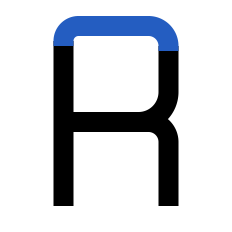

In [17]:
roundedness = Roundedness(
    top_left=15,
    top_right=20,
    mid_right_up=30,
    mid_right_down=20,
)

params = LogoParams(
    width=125,
    height=200,
    line_thickness=20,
    crossbar_pos=0.53,
    roundedness=roundedness,
    cap_color="#245dc1",
    # base_color="#000000",
)

svg = generate_logo_svg(
        params,
        # allow_invalid=True,
)

SVG(svg)

In [18]:
with open("logo.svg", "w") as f:
    f.write(svg)